
# Conjetura (FALSA)

> **“Todo número primo es de la forma $4k + 1$”**

---



## ¿Por qué parece razonable?

Si miras algunos primos:

- 5 = 4·1 + 1
- 13 = 4·3 + 1
- 17 = 4·4 + 1

Podría parecer que todos siguen ese patrón… pero esto es una **ilusión por muestra pequeña**.




# Método científico aplicado

1. **Observación:** algunos primos cumplen la forma
2. **Conjetura:** todos los primos cumplen la forma
3. **Experimentación (Python):** probar muchos casos
4. **Refutación:** encontrar un contraejemplo
5. **Conclusión:** la conjetura es falsa



# Script en Python


In [5]:
import sympy as sp

def es_de_la_forma_4k_mas_1(p):
    return p % 4 == 1

# Generar los primeros n primos
n = 50
primos = list(sp.primerange(1, 300))

contraejemplos = []

for p in primos:
    if not es_de_la_forma_4k_mas_1(p):
        contraejemplos.append(p)

print("Primeros primos analizados:")
print(primos[:20])

print("\nContraejemplos encontrados:")
print(contraejemplos[:10])



Primeros primos analizados:
[2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59, 61, 67, 71]

Contraejemplos encontrados:
[2, 3, 7, 11, 19, 23, 31, 43, 47, 59]



# ¿Qué obtendrás?

Entre los primeros resultados aparecen:

* 2
* 3
* 7
* 11
* 19

Por ejemplo:

* 3 ≡ 3 $mod\ 4$
* 7 ≡ 3 $mod\ 4$

- **Contraejemplo encontrado ⇒ conjetura falsa**



# Explicación matemática clave

En realidad, los números primos mayores que 2 se distribuyen así:

* Algunos son de la forma **$4k + 1$**
* Otros son de la forma **$4k + 3$**

Esto es fundamental en teoría de números (por ejemplo, en la suma de dos cuadrados).



# Versión didáctica para clase (muy potente)

Puedes plantearlo como actividad:

### Actividad

1. Generar los primeros 100 primos
2. Clasificarlos según:

   * $p \equiv 1 \pmod{4}$
   * $p \equiv 3 \pmod{4}$
3. Contar frecuencias
4. Visualizar resultados



# Extensión con visualización


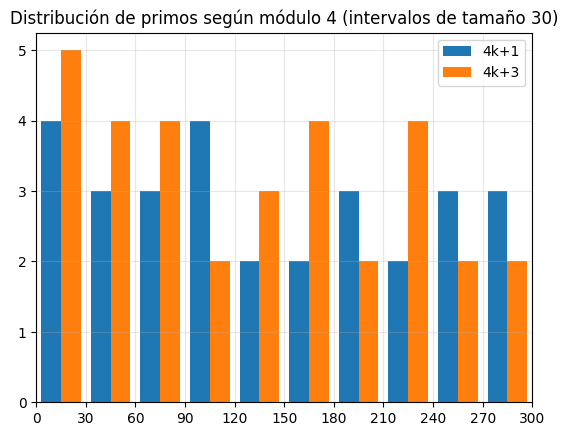

In [14]:
import matplotlib.pyplot as plt
import numpy as np

mod1 = []
mod3 = []

for p in primos:
    if p % 4 == 1:
        mod1.append(p)
    elif p % 4 == 3:
        mod3.append(p)

# Definir 10 intervalos en [0, 300]
bins = np.linspace(0, 300, 11)  # 11 bordes → 10 intervalos

plt.hist([mod1, mod3], bins=bins, label=['4k+1', '4k+3'])

plt.legend()
plt.title("Distribución de primos según módulo 4 (intervalos de tamaño 30)")
plt.grid(alpha=0.3)

# Clave: ticks exactamente en los extremos de los intervalos
plt.xticks(bins)

plt.xlim(0, 300)

plt.savefig(r"C:\Users\marco\Downloads\distribucion_de_primos.png")
plt.show()

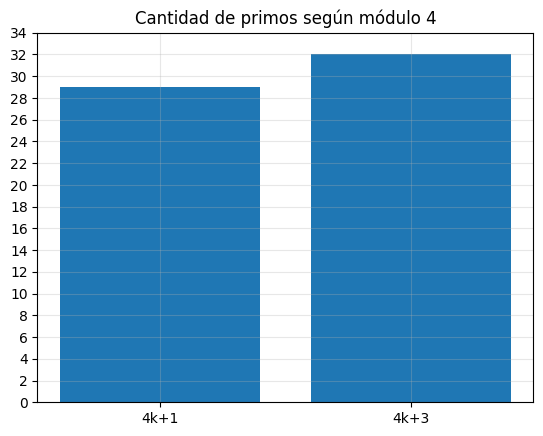

In [11]:
labels = ['4k+1', '4k+3']
counts = [len(mod1), len(mod3)]

plt.bar(labels, counts)

plt.title("Cantidad de primos según módulo 4")
plt.grid(alpha=0.3)
plt.yticks(np.arange(0,36, 2))
plt.show()


# Reflexión epistemológica (muy importante para tu enfoque docente)

Este ejemplo muestra que:

* **La evidencia empírica NO prueba una conjetura**
* Pero **un solo contraejemplo la destruye**
* Python actúa como:

  * laboratorio experimental
  * generador de evidencia
  * herramienta de pensamiento computacional




# Mensaje clave para tus estudiantes

> “En matemáticas, verificar mil casos no demuestra nada…
> pero un solo contraejemplo lo destruye todo.”

---


Vamos a subir el nivel con una conjetura **más profunda, históricamente relevante y perfecta para experimentar con Python**

---



# Conjetura (FALSA, nivel intermedio-alto)

> **“Todos los números de la forma (2^{2^n} + 1) son primos”**

Estos números se llaman **números de Fermat**, estudiados por
Pierre de Fermat.





## Observación inicial

Calculamos los primeros:

$$
F_n = 2^{2^n} + 1
$$

* $F_0 = 3$ → primo
* $F_1 = 5$ → primo
* (F_2 = 17) → primo
* (F_3 = 257) → primo
* $F_4 = 65537$ → primo

- ¡Parece una ley perfecta!

Fermat conjeturó que **todos eran primos**.



# Pero…

Leonhard Euler encontró:

$$
F_5 = 4294967297 = 641 \times 6700417
$$

- **Contraejemplo ⇒ conjetura falsa**



# Método científico computacional

1. Observamos patrón perfecto
2. Formulamos conjetura
3. Probamos con Python
4. Buscamos contraejemplo
5. Refutamos

---



# Script en Python (nivel más avanzado)



In [2]:
import sympy as sp

def fermat(n):
    return 2**(2**n) + 1

def analizar_fermat(max_n):
    resultados = []
    
    for n in range(max_n + 1):
        F = fermat(n)
        es_primo = sp.isprime(F)
        
        resultados.append((n, F, es_primo))
        
        print(f"F_{n} = {F}")
        print(f"¿Es primo? {es_primo}")
        
        if not es_primo:
            print("Factorización:")
            print(sp.factorint(F))
            print("-" * 40)
    
    return resultados

# Probar hasta n = 5 o 6 (cuidado: crece MUY rápido)
analizar_fermat(5)


F_0 = 3
¿Es primo? True
F_1 = 5
¿Es primo? True
F_2 = 17
¿Es primo? True
F_3 = 257
¿Es primo? True
F_4 = 65537
¿Es primo? True
F_5 = 4294967297
¿Es primo? False
Factorización:
{641: 1, 6700417: 1}
----------------------------------------


[(0, 3, True),
 (1, 5, True),
 (2, 17, True),
 (3, 257, True),
 (4, 65537, True),
 (5, 4294967297, False)]

# Observación computacional importante

* El crecimiento es **doblemente exponencial**
* $F_6$ ya es enorme $~(10^{19})$
* Esto introduce una idea clave:

- **Límites computacionales en matemáticas experimentales**



# Interpretación didáctica

El experimento mostrará:

* Los primeros casos validan la conjetura
* Pero un caso posterior la destruye

Esto es mucho más potente que el ejemplo anterior porque:

### Enseña tres ideas profundas

### 1. Peligro de la inducción empírica

5 casos correctos → conclusión falsa

---



### 2. Importancia del contraejemplo

No necesitas probar infinitos casos:

> basta uno para refutar

---



### 3. Rol de Python en matemáticas modernas

Python actúa como:

* laboratorio numérico
* detector de patrones
* herramienta de refutación

---



# Actividad tipo ABP (ideal para tu curso)

Plantea a tus estudiantes:

### Problema

> “¿Es cierto que todos los números de Fermat son primos?”

---



### Fases

1. **Exploración**

   * calcular (F_0) a (F_4)

2. **Hipótesis**

   * formular conjetura

3. **Experimentación**

   * probar $F_5$

4. **Refutación**

   * factorizar

5. **Reflexión**

   * discutir límites del empirismo

---



#  Reflexión epistemológica (nivel alto)

Este ejemplo conecta con:

* filosofía de la ciencia (falsacionismo de Karl Popper)
* matemática experimental
* computación simbólica

---



# Mensaje clave para estudiantes avanzados

> “En matemáticas, los patrones engañan…
> y mientras más bonitos son, más peligrosos pueden ser.”

---
